In [1]:
import importlib.util
import os
import random
import subprocess
import sys
from pathlib import Path
from typing import Optional

if importlib.util.find_spec("openpyxl") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
tf.config.list_physical_devices("GPU")
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "data").is_dir():
    REPO_ROOT = Path.cwd().resolve().parent
DATA_ROOT = REPO_ROOT / "data"

BTXRD_ROOT = DATA_ROOT / "BTXRD"
BTXRD_IMAGES = BTXRD_ROOT / "images"
BTXRD_XLSX = BTXRD_ROOT / "dataset.xlsx"
CKPT_DIR = REPO_ROOT / "models" / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

BTXRD_MODEL_PATH = CKPT_DIR / "btxrd_from_mura.keras"

IMG_SIZE = 224
BATCH_SIZE = 32

LR = 1e-4

assert BTXRD_IMAGES.is_dir(), f"Missing {BTXRD_IMAGES}"
assert BTXRD_XLSX.is_file(), f"Missing {BTXRD_XLSX}"
print("DATA_ROOT:", DATA_ROOT)

DATA_ROOT: /Users/adyan/Desktop/COSC 4337/Bone-Cancer-Detection/data


In [4]:
def decode_image(path, label, size):
    data = tf.io.read_file(path)
    img = tf.io.decode_image(data, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [size, size])
    img = tf.cast(img, tf.float32)
    return img, label


def make_dataset(paths, labels, *, size, batch_size, shuffle):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(min(len(paths), 10_000), reshuffle_each_iteration=True)
    ds = ds.map(
        lambda p, y: decode_image(p, y, size),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [5]:
def resolve_image_path(images_dir: Path, image_id: str) -> Optional[Path]:
    p = images_dir / str(image_id).strip()
    if p.is_file():
        return p
    stem = Path(str(image_id)).stem
    for ext in (".jpeg", ".jpg", ".png", ".JPEG", ".JPG", ".PNG"):
        c = images_dir / f"{stem}{ext}"
        if c.is_file():
            return c
    return None

btxrd_df = pd.read_excel(BTXRD_XLSX, engine="openpyxl")
btxrd_df.columns = [str(c).strip() for c in btxrd_df.columns]
if "tumor" not in btxrd_df.columns:
    raise KeyError(f"Expected a 'tumor' column; got: {list(btxrd_df.columns)}")

rows = []
for _, r in btxrd_df.iterrows():
    img_id = r["image_id"]
    p = resolve_image_path(BTXRD_IMAGES, img_id)
    if p is None:
        continue
    rows.append((p.as_posix(), int(r["tumor"])))

btx_paths = [a for a, _ in rows]
btx_labels = np.array([b for _, b in rows], dtype="float32")
print("BTXRD samples with files on disk:", len(btx_paths))
print("Tumor rate:", float(btx_labels.mean()))

b_train_p, b_val_p, b_train_y, b_val_y = train_test_split(
    btx_paths, btx_labels, test_size=0.2, random_state=42, stratify=btx_labels
)
print("BTXRD train / val:", len(b_train_p), len(b_val_p))

BTXRD samples with files on disk: 3746
Tumor rate: 0.4983983039855957
BTXRD train / val: 2996 750


In [6]:
btx_train_ds = make_dataset(
    b_train_p, b_train_y.tolist(),
    size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True,
)
btx_val_ds = make_dataset(
    b_val_p, b_val_y.tolist(),
    size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False,
)

2026-04-26 03:37:02.715045: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-26 03:37:02.715096: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-04-26 03:37:02.715106: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-04-26 03:37:02.715161: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-26 03:37:02.715179: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [7]:
def build_baseline_model():

    model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (5, 5), padding="same", activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(64, (5,5), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    tf.keras.layers.Conv2D(128, (5, 5), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)
    return model

In [8]:
def build_improved_model():
    model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Rescaling(1./255),

    # --- Block 1: Implementing stacked 3x3s with batch norm. ---
    tf.keras.layers.Conv2D(32, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    
    tf.keras.layers.Conv2D(32, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # --- Block 2: Increase depth. ---
    tf.keras.layers.Conv2D(64, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Conv2D(64, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # --- Block 3: Dense Head. ---
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)
    return model

In [9]:
def build_augmented_model():
    data_augmentation = tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.05),      # about +/- 18 degrees
            tf.keras.layers.RandomZoom(0.10),
            tf.keras.layers.RandomTranslation(
                height_factor=0.10,
                width_factor=0.10,
                fill_mode="nearest",
            ),
            tf.keras.layers.RandomContrast(0.15),
        ],
        name="data_augmentation",
    )

    model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
            data_augmentation,
            tf.keras.layers.Rescaling(1./255),

            # --- Block 1: Implementing stacked 3x3s with batch norm. ---
            tf.keras.layers.Conv2D(32, (3, 3), padding="same"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            tf.keras.layers.Conv2D(32, (3, 3), padding="same"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

            # --- Block 2: Increase depth. ---
            tf.keras.layers.Conv2D(64, (3, 3), padding="same"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            tf.keras.layers.Conv2D(64, (3, 3), padding="same"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

            # --- Block 3: Dense Head. ---
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dense(256),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)
    return model

In [23]:
def count_trainable_params(model):
    return int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))


def count_non_trainable_params(model):
    return int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))


def train_model(build_model_fn, train_ds, val_ds):
    epochs = [5, 10, 25, 50]
    results = {}

    for epoch in epochs:
        model = build_model_fn()

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epoch,
            verbose=0,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_loss',
                    patience=10,
                    restore_best_weights=True,
                )
            ],
        )

        results[epoch] = {
            "model_name": model.name,
            "history": history.history,
            "total_params": model.count_params(),
            "trainable_params": count_trainable_params(model),
            "non_trainable_params": count_non_trainable_params(model),
        }

    return results


def train_baseline(train_ds, val_ds):
    return train_model(build_baseline_model, train_ds, val_ds)


def train_improved(train_ds, val_ds):
    return train_model(build_improved_model, train_ds, val_ds)


def train_augmented(train_ds, val_ds):
    return train_model(build_augmented_model, train_ds, val_ds)

In [24]:
def plot_learning_curves(results):

    for epoch_count, result in results.items():
        history = result["history"]
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))

        ax[0].plot(history["loss"], label="Train loss")
        ax[0].plot(history["val_loss"], label="Val loss")
        ax[0].set_title(f"Loss curve: {epoch_count} epochs")
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Loss")
        ax[0].legend()

        ax[1].plot(history["accuracy"], label="Train accuracy")
        ax[1].plot(history["val_accuracy"], label="Val accuracy")
        ax[1].set_title(f"Accuracy curve: {epoch_count} epochs")
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Accuracy")
        ax[1].legend()

        plt.show()


def show_param_counts(results):
    for epoch_count, result in results.items():
        print(f"Model trained for {epoch_count} epochs:")
        print(f"  Model name: {result['model_name']}")
        print(f"  Total params: {result['total_params']:,}")
        print(f"  Trainable params: {result['trainable_params']:,}")
        print(f"  Non-trainable params: {result['non_trainable_params']:,}")
        print()

In [25]:
baseline_results = train_baseline(btx_train_ds, btx_val_ds)

In [26]:
show_param_counts(baseline_results)

Model trained for 5 epochs:
  Model name: sequential_4
  Total params: 13,103,937
  Trainable params: 13,103,937
  Non-trainable params: 0

Model trained for 10 epochs:
  Model name: sequential_5
  Total params: 13,103,937
  Trainable params: 13,103,937
  Non-trainable params: 0

Model trained for 25 epochs:
  Model name: sequential_6
  Total params: 13,103,937
  Trainable params: 13,103,937
  Non-trainable params: 0

Model trained for 50 epochs:
  Model name: sequential_7
  Total params: 13,103,937
  Trainable params: 13,103,937
  Non-trainable params: 0



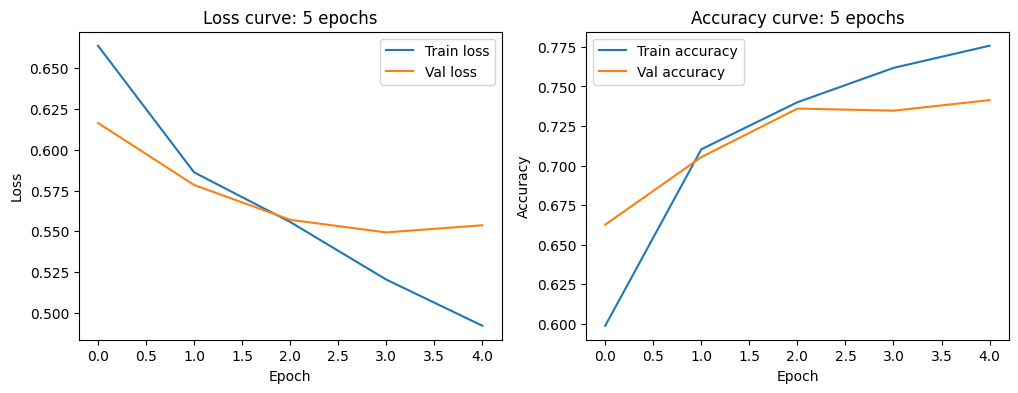

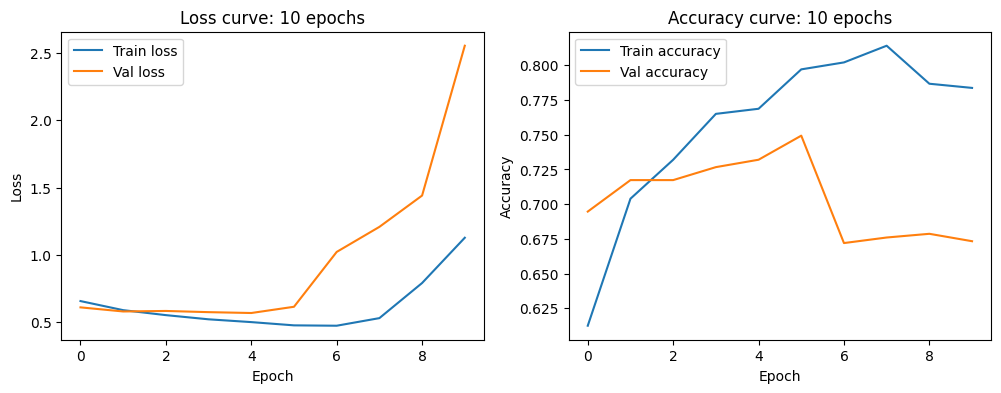

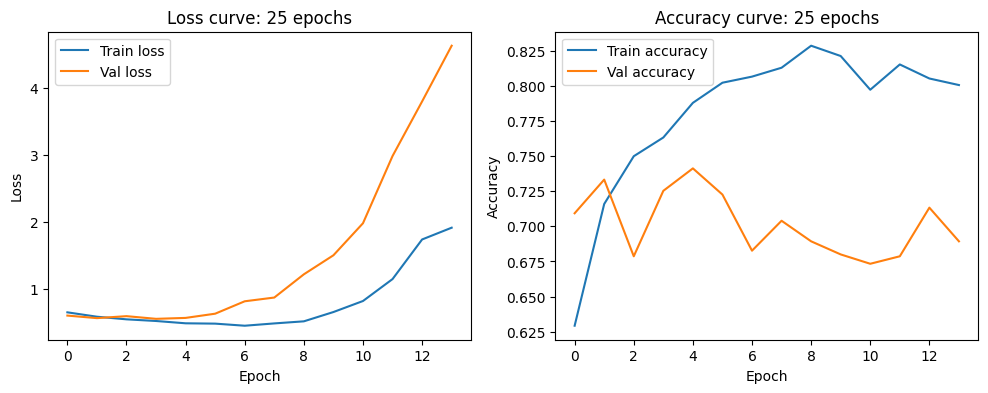

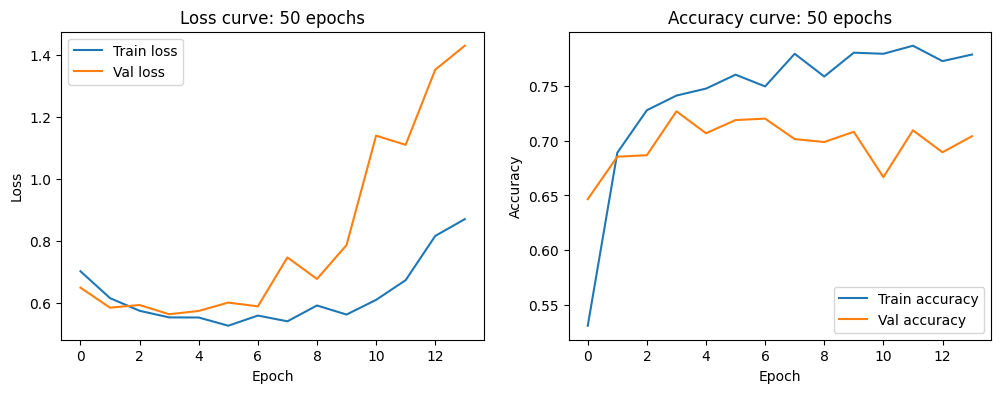

In [27]:
plot_learning_curves(baseline_results)

In [28]:
improved_results = train_improved(btx_train_ds, btx_val_ds)

In [29]:
show_param_counts(improved_results)

Model trained for 5 epochs:
  Model name: sequential_8
  Total params: 84,257
  Trainable params: 83,361
  Non-trainable params: 896

Model trained for 10 epochs:
  Model name: sequential_9
  Total params: 84,257
  Trainable params: 83,361
  Non-trainable params: 896

Model trained for 25 epochs:
  Model name: sequential_10
  Total params: 84,257
  Trainable params: 83,361
  Non-trainable params: 896

Model trained for 50 epochs:
  Model name: sequential_11
  Total params: 84,257
  Trainable params: 83,361
  Non-trainable params: 896



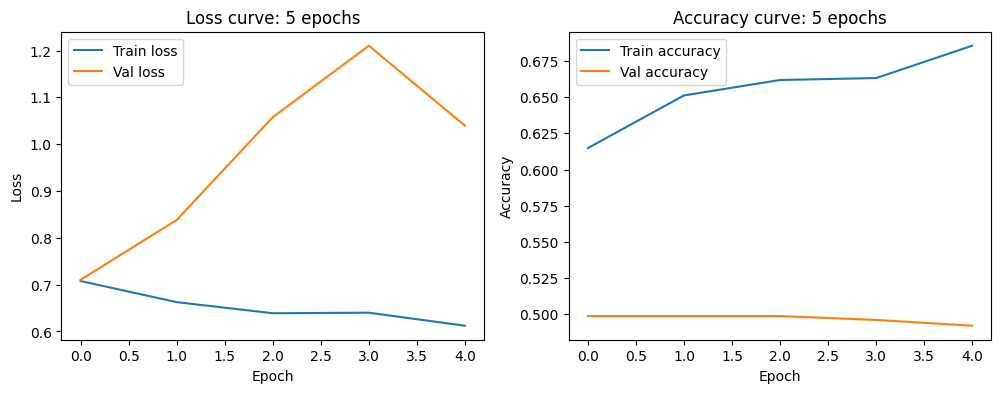

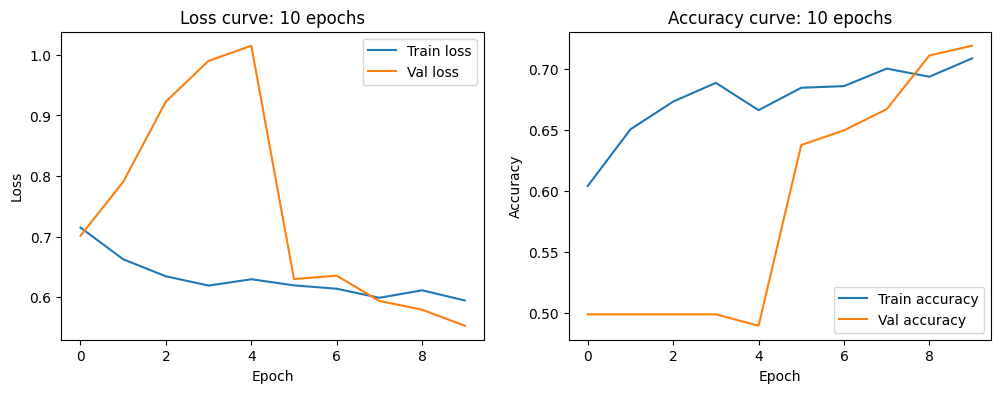

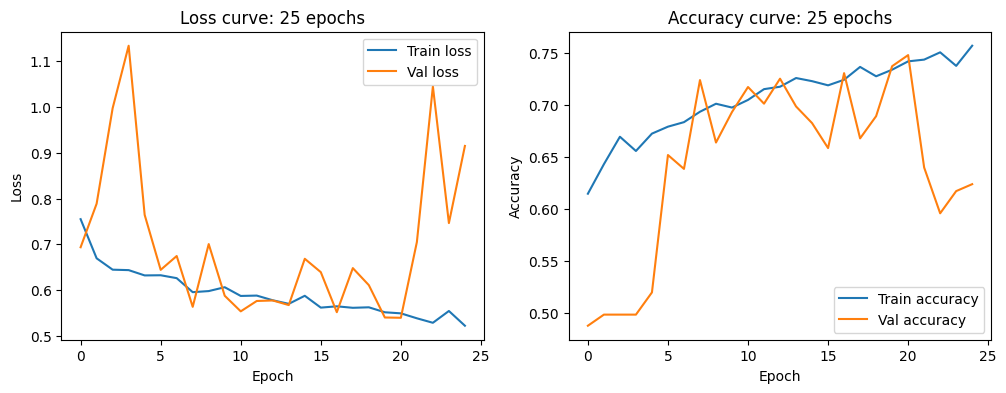

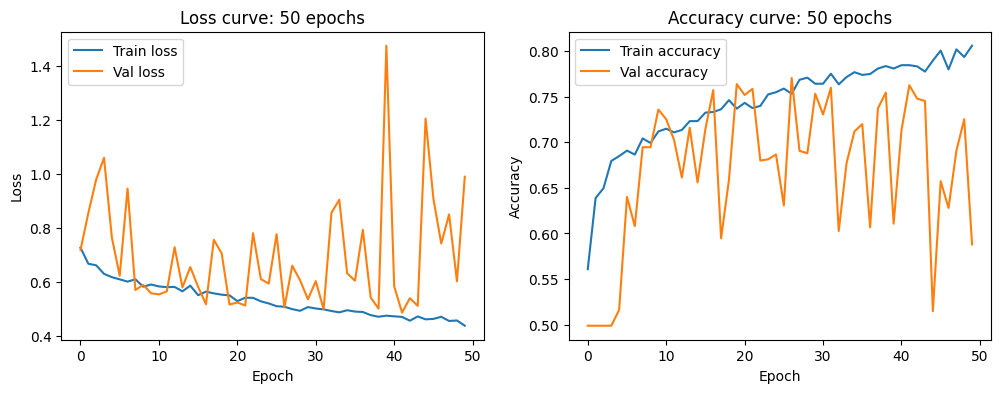

In [30]:
plot_learning_curves(improved_results)

In [31]:
def print_metrics(results, model_label):
    print(f"\n{model_label}")

    for epoch_count, result in results.items():
        history = result["history"]

        print(f"\nMetrics for {epoch_count} epochs:")
        print(f"  Train loss: {history['loss'][-1]:.4f}")
        print(f"  Train accuracy: {history['accuracy'][-1]:.4f}")
        print(f"  Train AUC: {history['auc'][-1]:.4f}")
        print(f"  Val loss: {history['val_loss'][-1]:.4f}")
        print(f"  Val accuracy: {history['val_accuracy'][-1]:.4f}")
        print(f"  Val AUC: {history['val_auc'][-1]:.4f}")

In [32]:
print_metrics(baseline_results, "Baseline Model")
print_metrics(improved_results, "Improved Model")


Baseline Model

Metrics for 5 epochs:
  Train loss: 0.4921
  Train accuracy: 0.7757
  Train AUC: 0.8485
  Val loss: 0.5537
  Val accuracy: 0.7413
  Val AUC: 0.8031

Metrics for 10 epochs:
  Train loss: 1.1272
  Train accuracy: 0.7837
  Train AUC: 0.8464
  Val loss: 2.5526
  Val accuracy: 0.6733
  Val AUC: 0.7390

Metrics for 25 epochs:
  Train loss: 1.9134
  Train accuracy: 0.8007
  Train AUC: 0.8474
  Val loss: 4.6315
  Val accuracy: 0.6893
  Val AUC: 0.7306

Metrics for 50 epochs:
  Train loss: 0.8697
  Train accuracy: 0.7784
  Train AUC: 0.8489
  Val loss: 1.4304
  Val accuracy: 0.7040
  Val AUC: 0.7677

Improved Model

Metrics for 5 epochs:
  Train loss: 0.6123
  Train accuracy: 0.6856
  Train AUC: 0.7460
  Val loss: 1.0396
  Val accuracy: 0.4920
  Val AUC: 0.6124

Metrics for 10 epochs:
  Train loss: 0.5947
  Train accuracy: 0.7083
  Train AUC: 0.7707
  Val loss: 0.5530
  Val accuracy: 0.7187
  Val AUC: 0.8010

Metrics for 25 epochs:
  Train loss: 0.5220
  Train accuracy: 0.7570
